plant_name               0
timestamp                0
wind_speed               0
turbulence_intensity     0
nacelle_direction        0
rotor_speed              0
generator_speed          0
blade_angle_1            0
blade_angle_2            0
blade_angle_3            0
power                    0
cosphi                   0
temp_environment         0
generator_temperature    0
break_temperature        0
temp_hydraulic_oil       0
bearing_temperature      0
hydraulic_pressure       0
gear_pressure            0
wind_direction           0
wind_speed_reference     0
airpressure              0
humidity                 0
errorcode                0
dtype: int64
Fault class distribution:
 errorcode
0    432808
1     37645
Name: count, dtype: int64


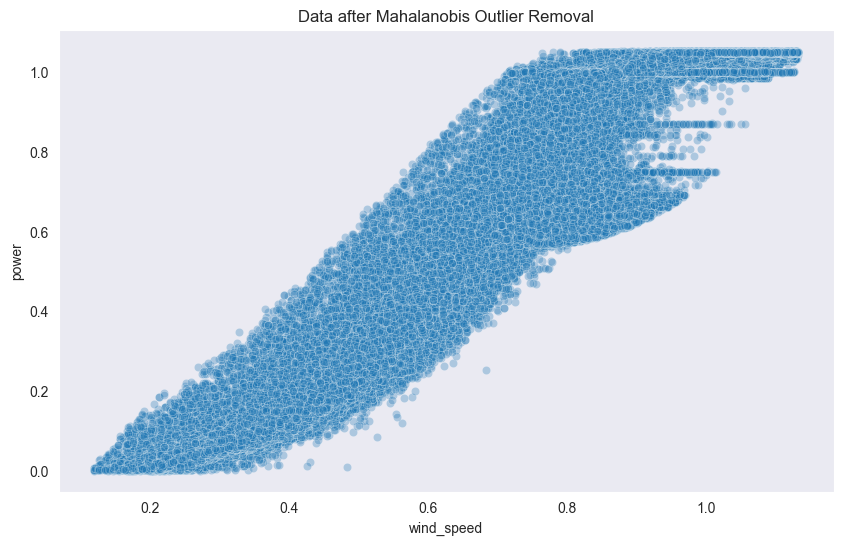

Data size after outlier filtering: 448114 records
Remaining missing values: 0


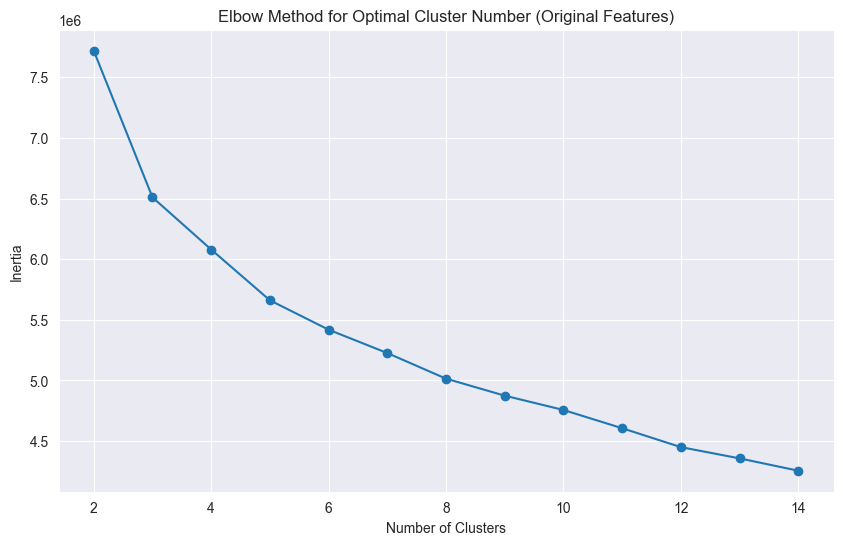

Reduced to 12 principal components
Explained variance ratio: 0.96


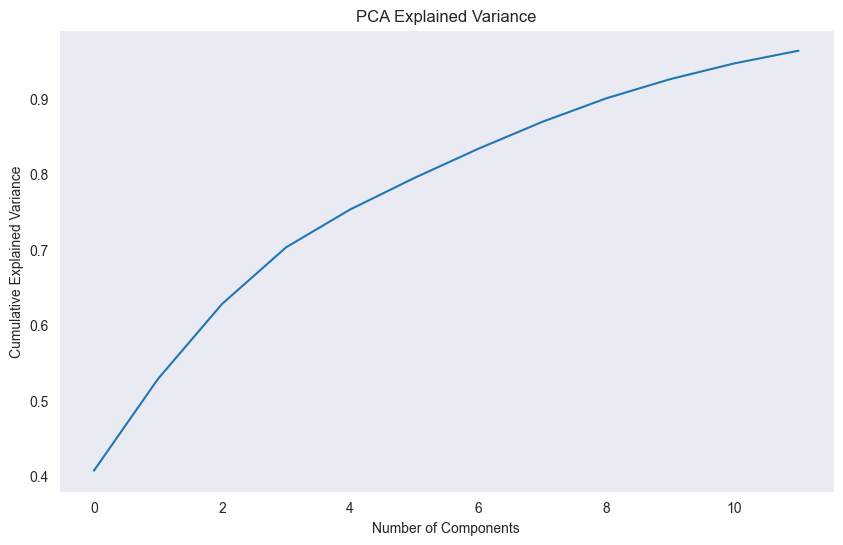

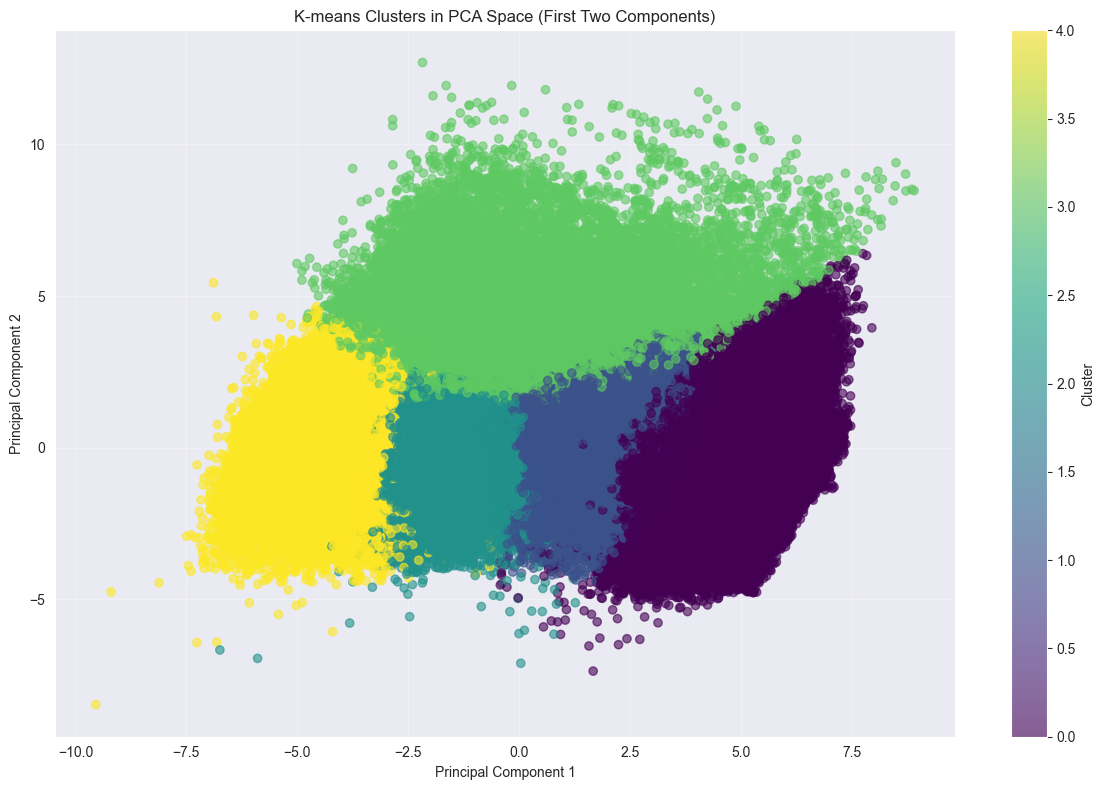


Cluster Analysis Complete
Cluster distribution:
cluster
2    133586
1    112332
0     89687
4     85588
3     26921
Name: count, dtype: int64

TTF Dataset Prepared: 27738 records
Time-to-Failure range: 0.2 to 15.0 hours

Model Comparison - MAE Results by Turbine (hours):
Turbine ID | XGBoost MAE | RF MAE | Records
--------------------------------------------
      109 | 3.32 | 3.23 |    3725
      114 | 3.17 | 3.18 |    3732
      115 | 3.66 | 3.37 |    7079
      116 | 3.45 | 3.37 |    9753
      120 | 3.04 | 3.04 |    3449


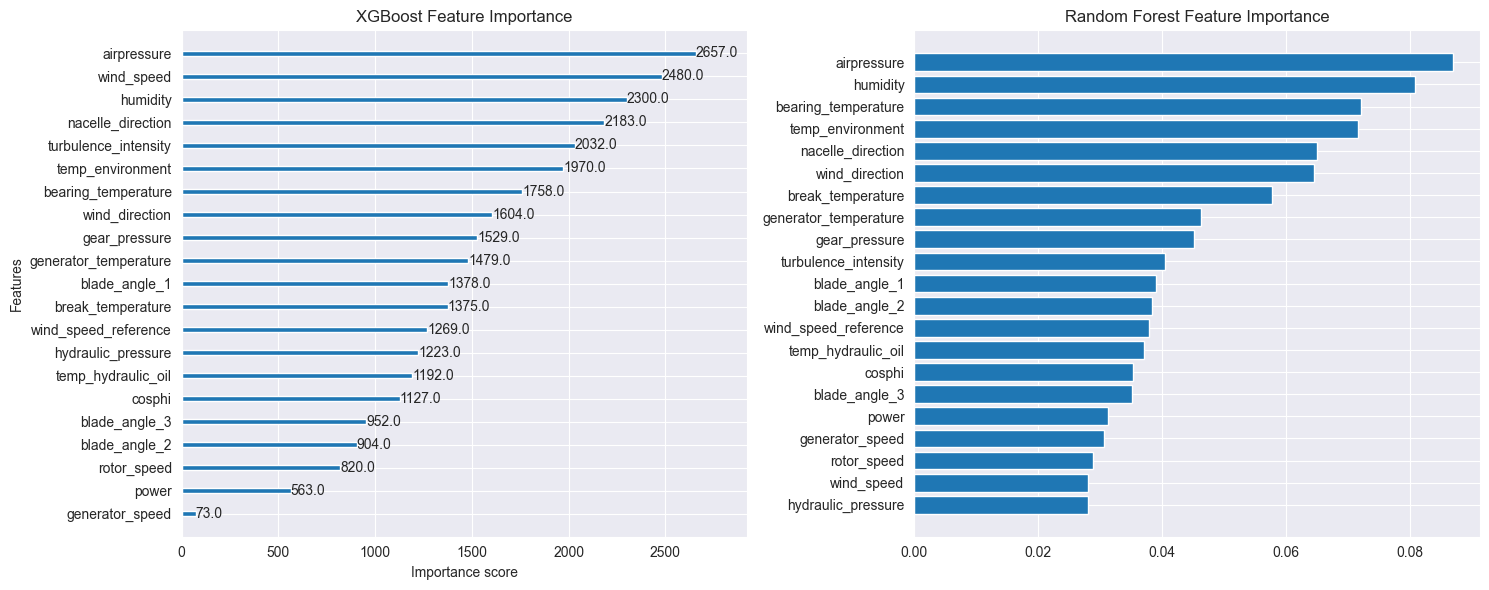

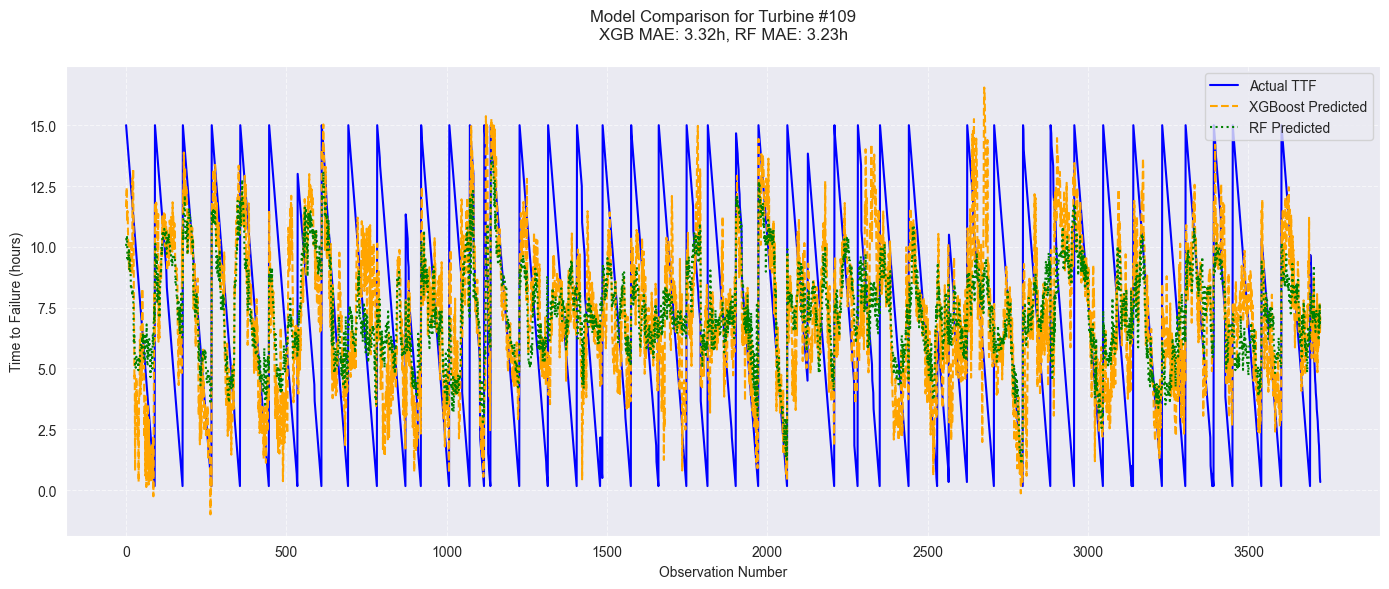

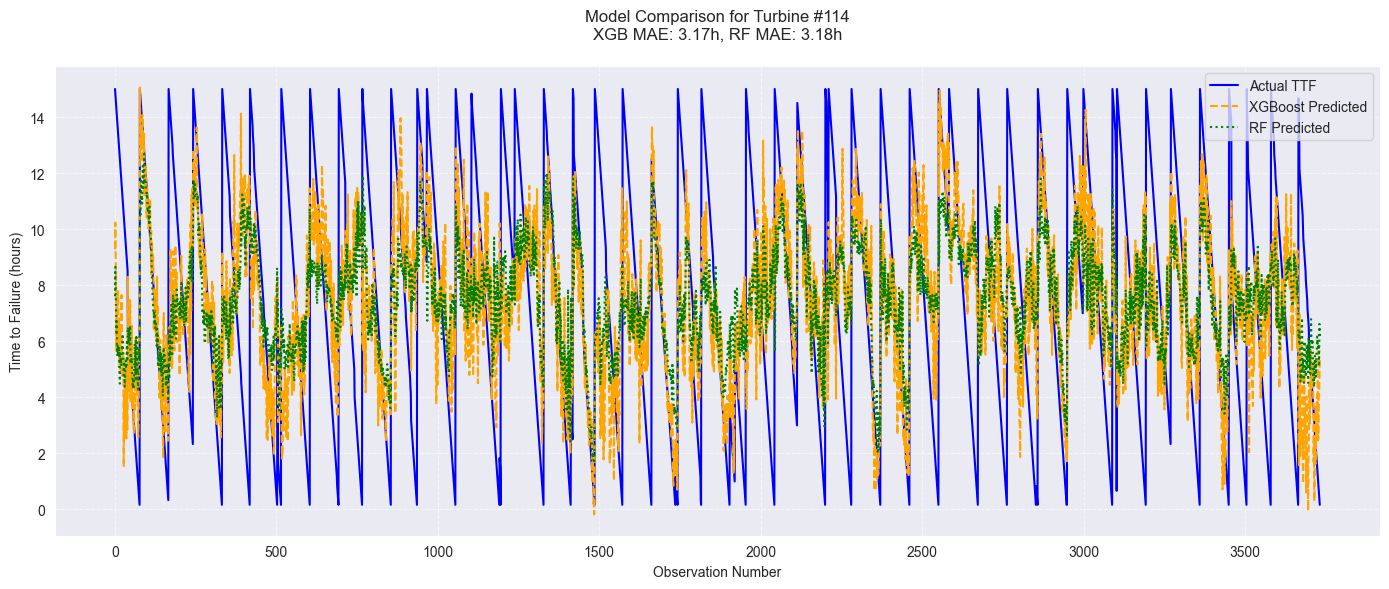

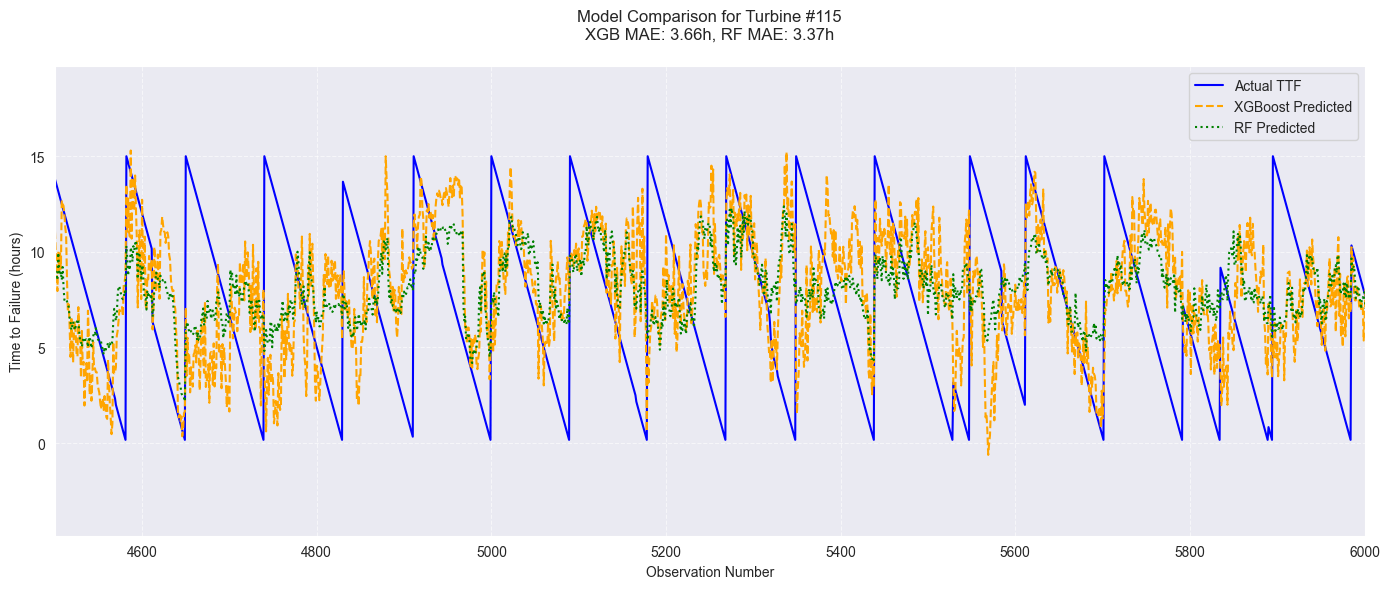

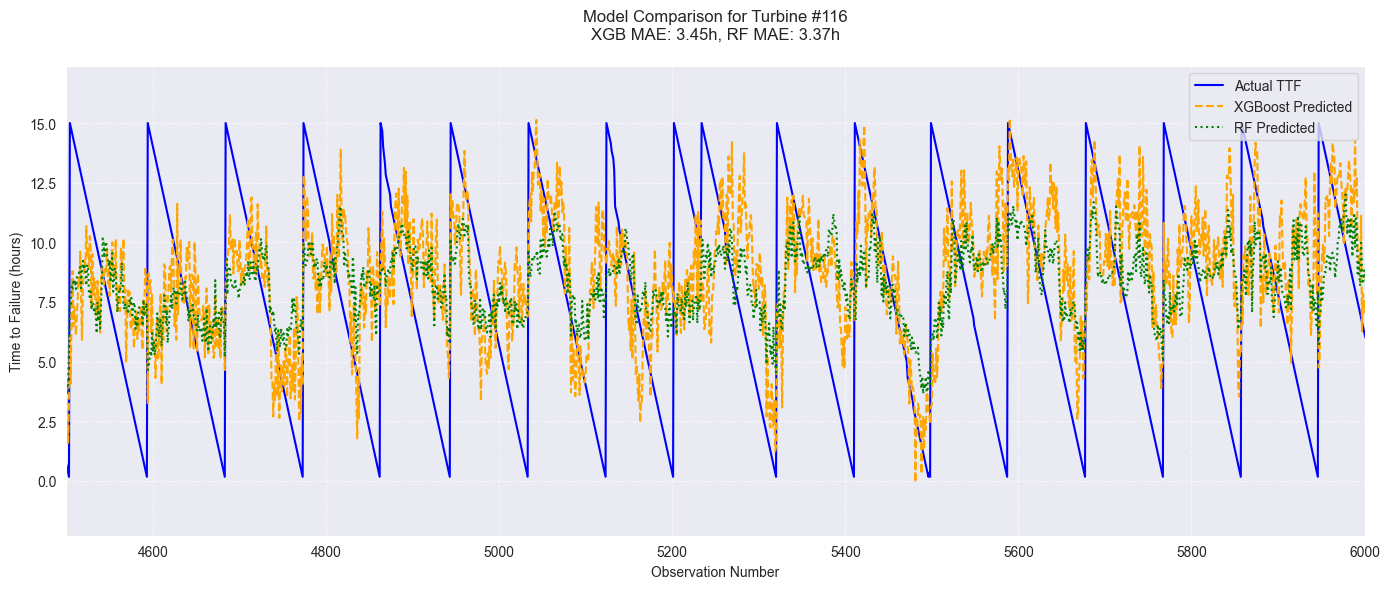

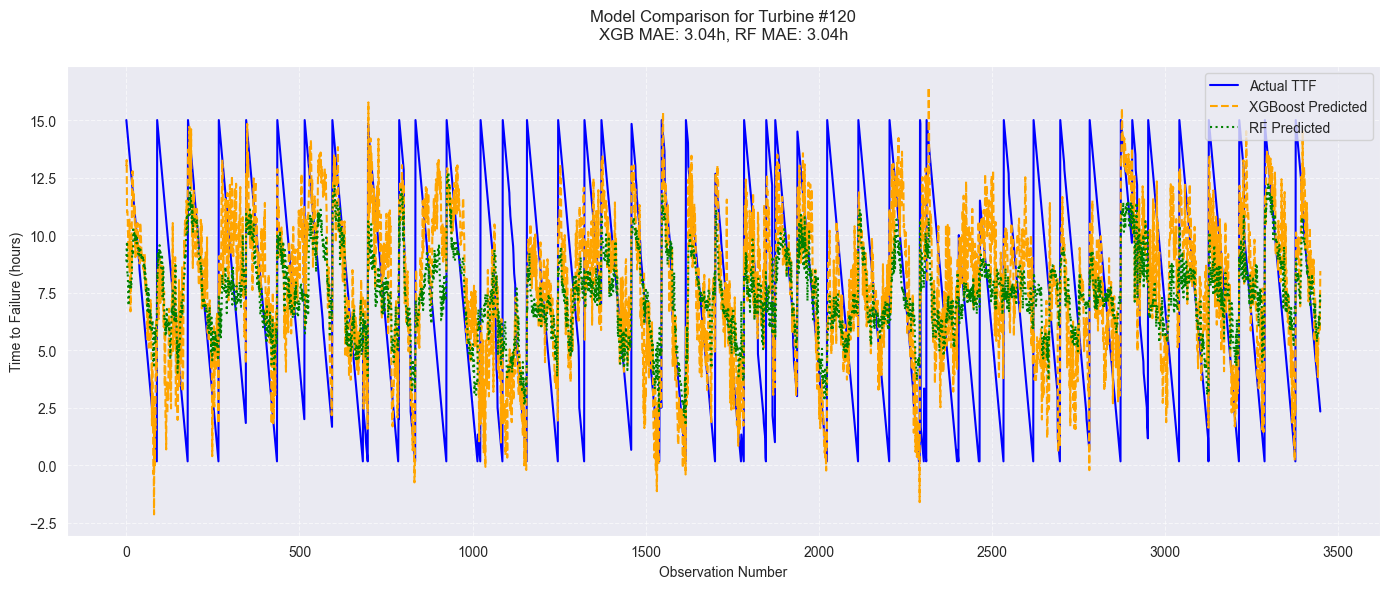


Generating SHAP explanations...

Optimizing models for turbine 109...
Running Bayesian Optimization for XGBoost...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits

<Figure size 1500x600 with 0 Axes>

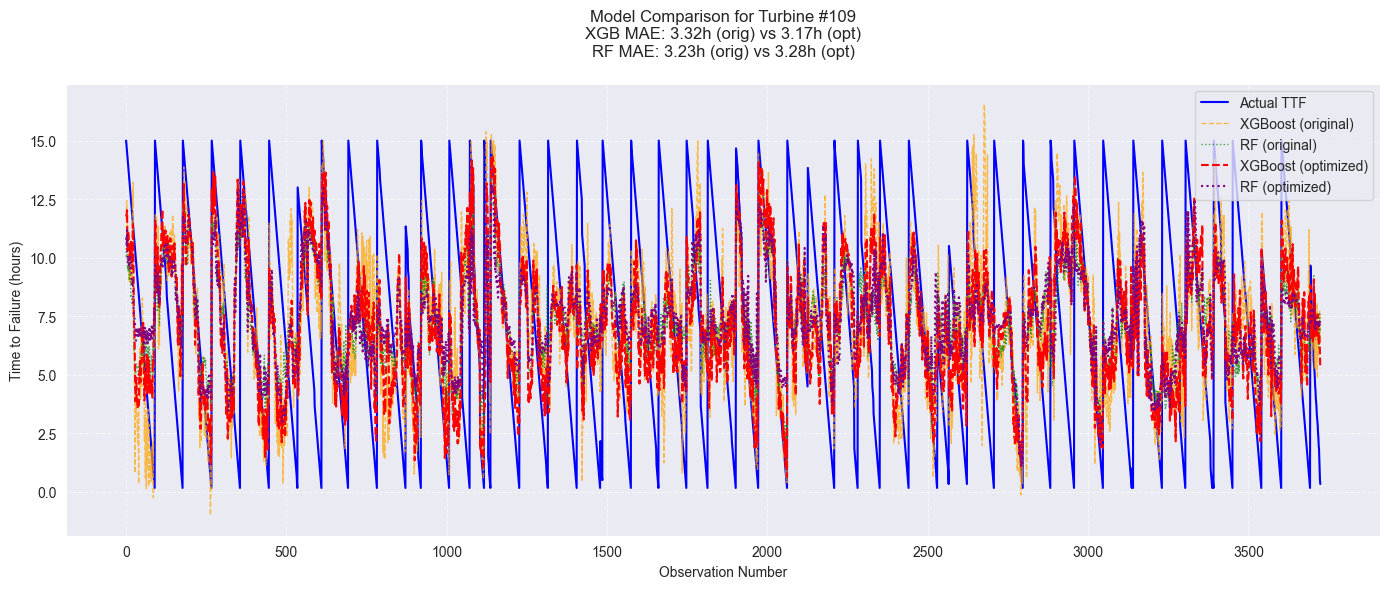

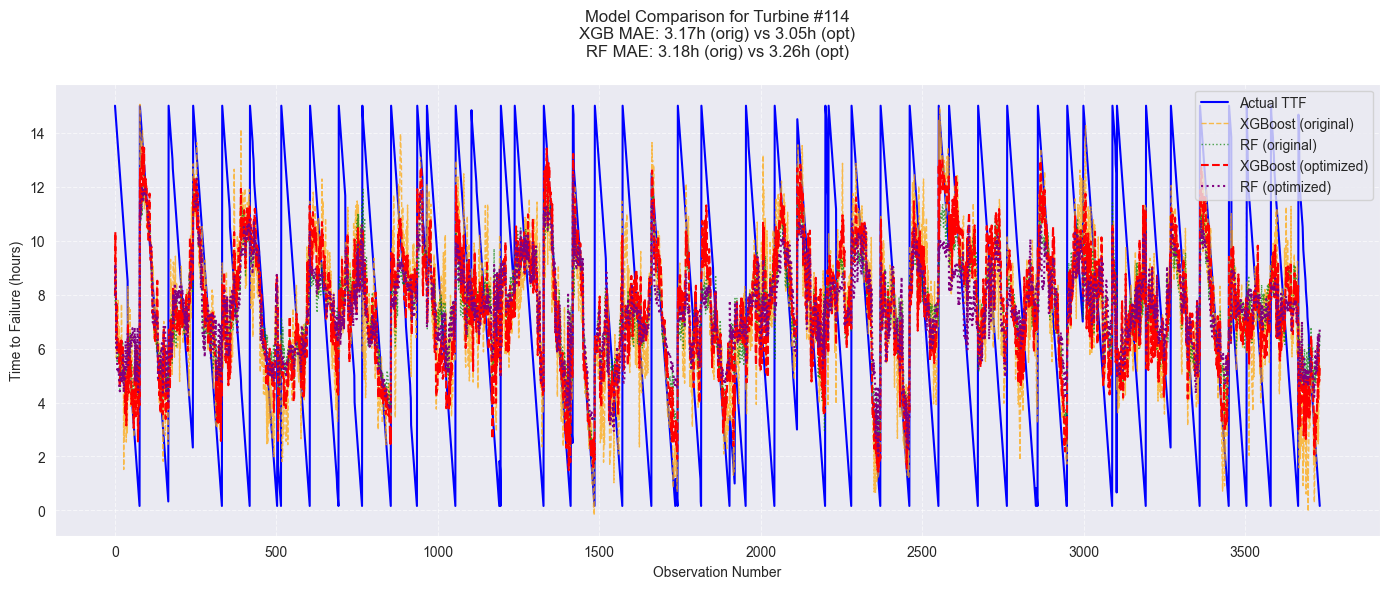

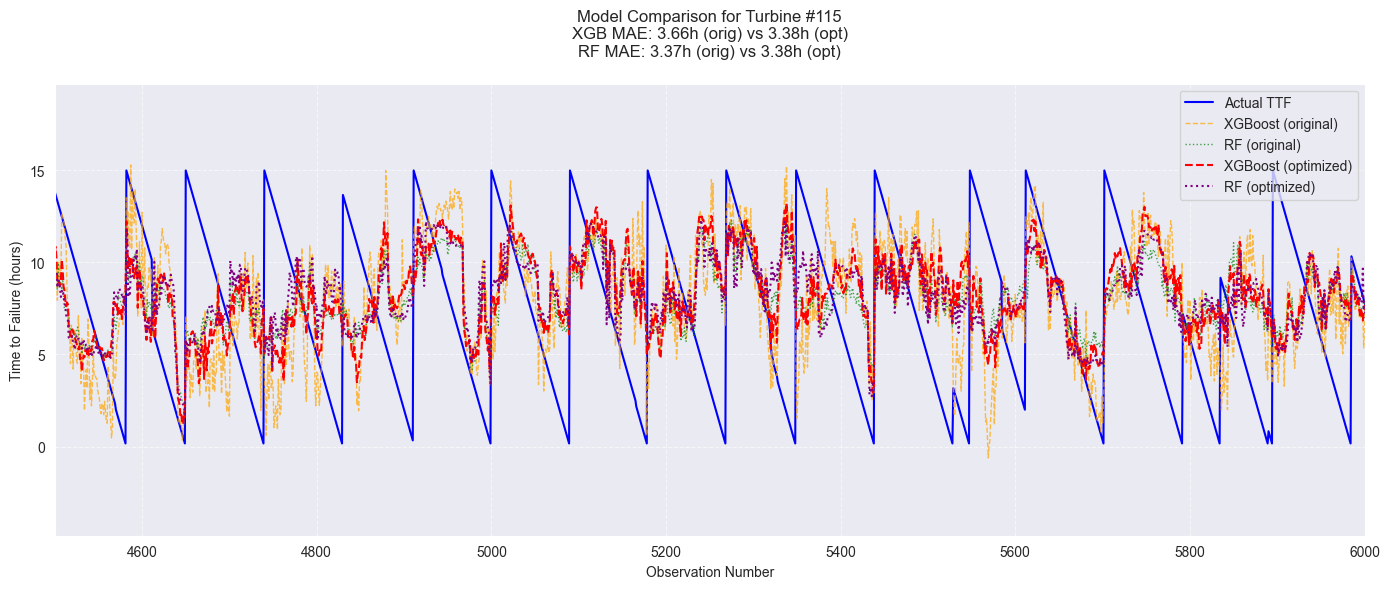

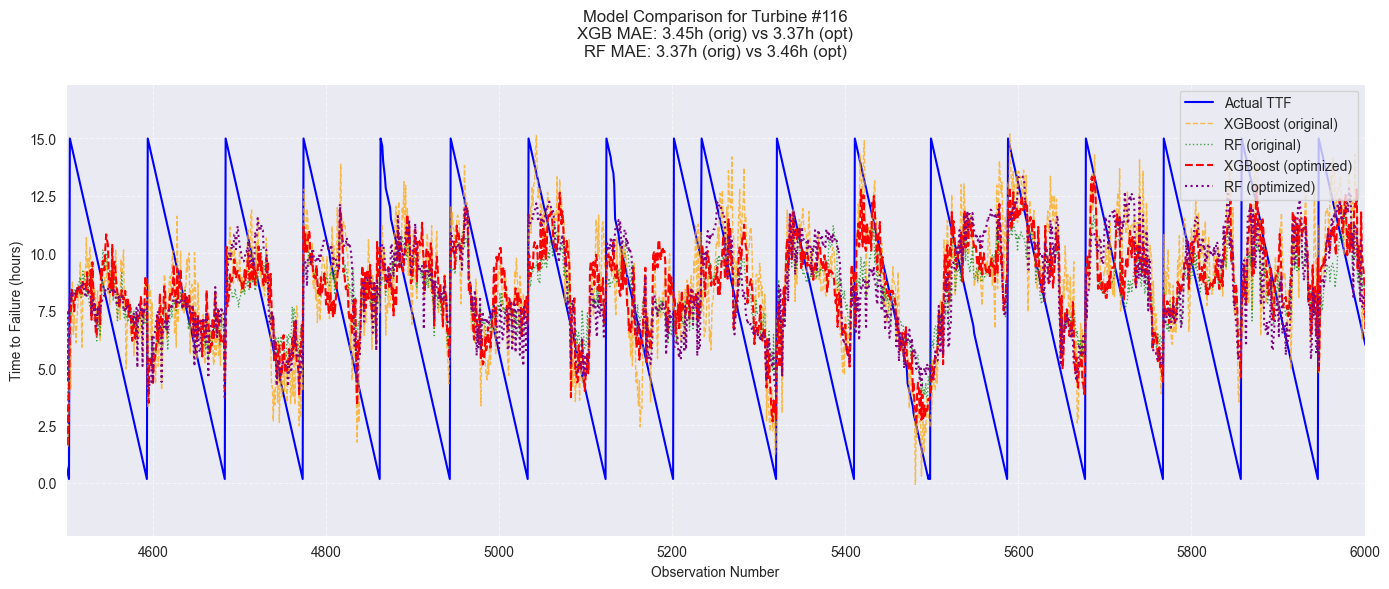

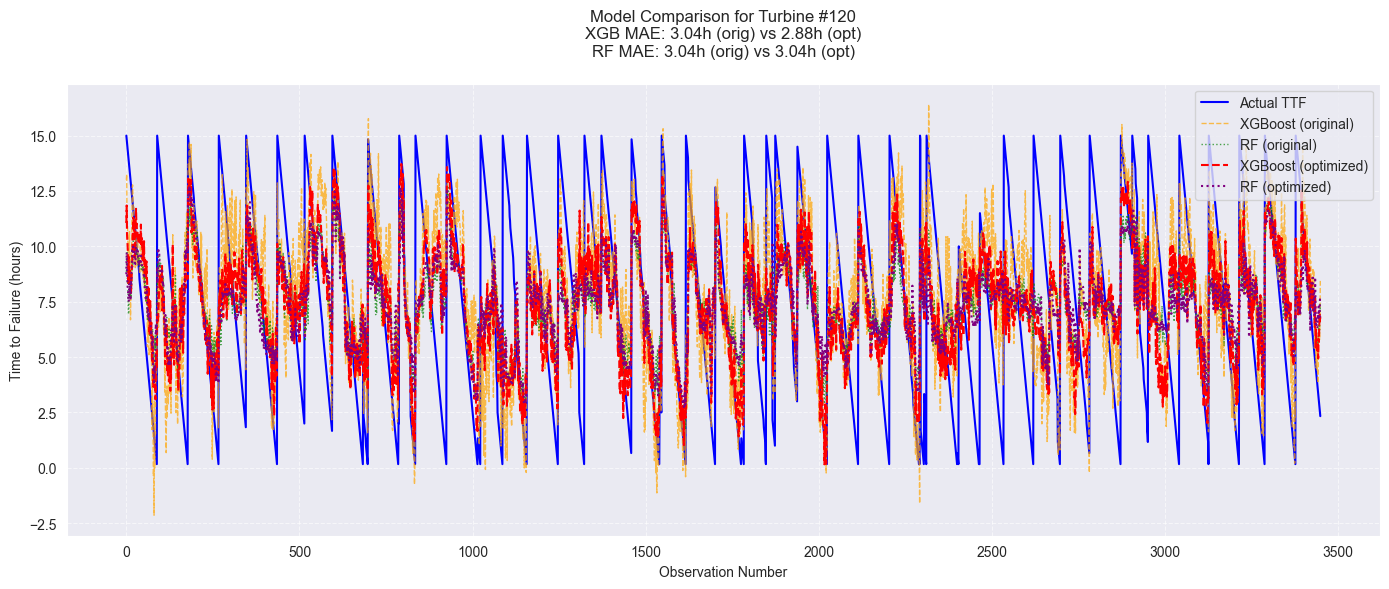

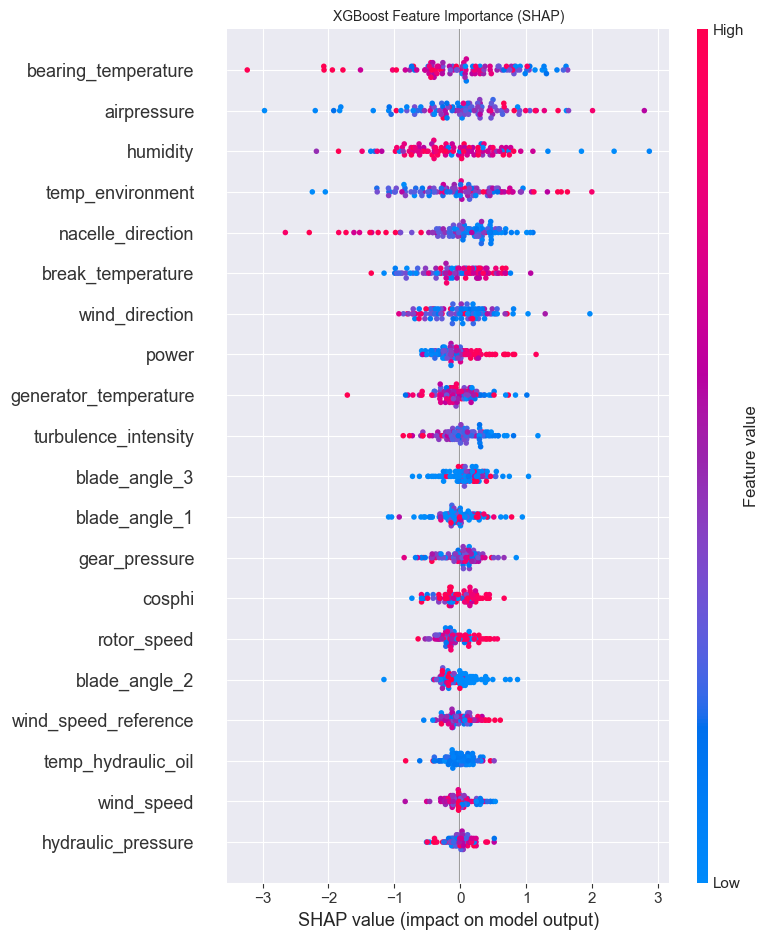

  0%|          | 0/100 [00:00<?, ?it/s]

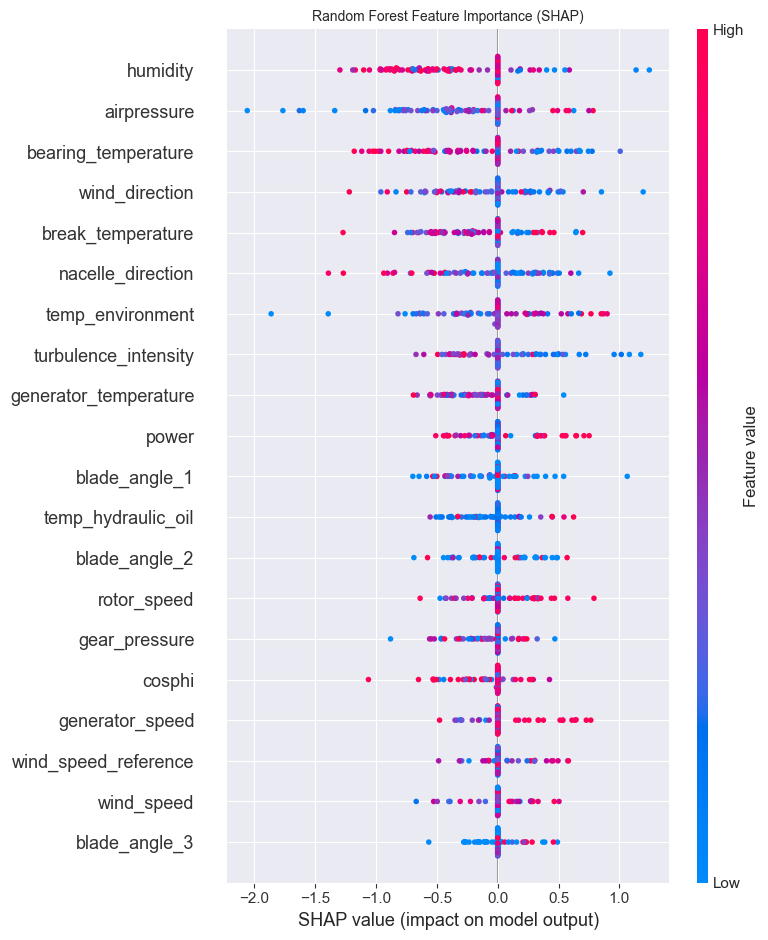

In [2]:
    # Import Packages
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.decomposition import PCA
    from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
    from sklearn.feature_selection import SelectKBest, mutual_info_classif
    from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
    from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                                 mean_absolute_error, precision_recall_curve, roc_curve, auc)
    from sklearn.neighbors import LocalOutlierFactor
    from sklearn.cluster import AgglomerativeClustering
    from sklearn.manifold import TSNE
    from xgboost import XGBClassifier, XGBRegressor
    from sklearn.preprocessing import LabelEncoder
    from sklearn.model_selection import LeaveOneGroupOut
    from sklearn.cluster import KMeans
    from sklearn.feature_selection import mutual_info_classif
    import xgboost as xgb
    from sklearn.feature_selection import SelectFromModel
    from scipy.spatial.distance import mahalanobis

    import shap
    from tqdm import tqdm
    import warnings

    warnings.filterwarnings('ignore')

    # Load and Visualize SCADA Dataset
    # Load data
    data = pd.read_csv('wedowind.csv')
    data.drop('Unnamed: 0', axis=1, inplace=True)
    data = data[(data['power'] > 0) & (data['rotor_speed'] > 0)]

    # Check missing values
    print(data.isnull().sum())
    data['timestamp'] = pd.to_datetime(data['timestamp'])
    print("Fault class distribution:\n", data["errorcode"].value_counts())  # Assuming 'errorcode' is the target


    # Pre-processing
    # Mahalanobis outlier filtering function
    def filter_outliers(df, variables, threshold=3.0):
        """Filter outliers using Mahalanobis distance"""
        # Drop rows with missing values in the selected variables
        df_clean = df.dropna(subset=variables)

        # Calculate covariance matrix and its inverse
        cov = np.cov(df_clean[variables].T)
        try:
            inv_cov = np.linalg.inv(cov)
        except np.linalg.LinAlgError:
            # If matrix is singular, use pseudo-inverse
            inv_cov = np.linalg.pinv(cov)

        mean = np.mean(df_clean[variables], axis=0)

        # Calculate Mahalanobis distance for each point
        distances = []
        for _, row in df_clean[variables].iterrows():
            try:
                dist = mahalanobis(row, mean, inv_cov)
            except:
                dist = np.nan
            distances.append(dist)

        distances = np.array(distances)
        return df_clean[distances < threshold]


    # Apply Mahalanobis filtering
    variables_to_filter = ['power', 'wind_speed', 'rotor_speed']  # Add relevant variables
    data = filter_outliers(data, variables_to_filter, threshold=3.0)

    # Visualize the filtering effect
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='wind_speed', y='power', data=data, alpha=0.3)
    plt.title('Data after Mahalanobis Outlier Removal')
    plt.grid()
    plt.show()

    print(f"Data size after outlier filtering: {len(data)} records")

    # Continue with your existing preprocessing
    data['hour'] = data['timestamp'].dt.hour
    data['day_of_week'] = data['timestamp'].dt.dayofweek
    data['day_of_year'] = data['timestamp'].dt.dayofyear
    # Prepare features for clustering
    features = data.drop(['timestamp', 'plant_name', 'errorcode'], axis=1)

    # Handle missing values - two options:

    # Option 1: Drop rows with any missing values (if few missing values)
    data_cleaned = data.dropna().copy()
    features_cleaned = features.dropna().copy()

    # Verify no missing values remain
    print(f"Remaining missing values: {features_cleaned.isna().sum().sum()}")
    # Scale features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_cleaned)

    # Unsupervised Learning for Feature Selection
    # Determine optimal number of clusters on original scaled features
    inertia = []
    for k in range(2, 15):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(scaled_features)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(range(2, 15), inertia, marker='o')
    plt.title('Elbow Method for Optimal Cluster Number (Original Features)')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()
    # Fit with optimal clusters (using 5 as in your original code)
    kmeans = KMeans(n_clusters=5, random_state=42)
    clusters = kmeans.fit_predict(scaled_features)
    data_cleaned['cluster'] = clusters
    # Now perform PCA for visualization and analysis
    pca = PCA(n_components=0.95)
    principal_components = pca.fit_transform(scaled_features)
    print(f"Reduced to {principal_components.shape[1]} principal components")
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}")
    # Plot explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Explained Variance')
    plt.grid()
    plt.show()

    # Visualize clusters in PCA space
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(principal_components[:, 0],
                          principal_components[:, 1],
                          c=clusters, cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, label='Cluster')
    plt.title('K-means Clusters in PCA Space (First Two Components)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nCluster Analysis Complete")
    print(f"Cluster distribution:\n{data_cleaned['cluster'].value_counts()}")

    # Supervised Learning
    # First create binary failure indicator
    data_cleaned['failure'] = (data_cleaned['errorcode'] != 0).astype(int)


    # Your exact TTF calculation function
    def create_ttf_feature(group):
        """Create Time-to-Failure feature following paper's exact methodology"""
        group = group.sort_values('timestamp')
        group['ttf'] = 0.0

        failure_indices = group.index[group['failure'] == 1].tolist()

        # Calculate time until next failure for each point
        for i in range(len(group)):
            current_time = group.iloc[i]['timestamp']
            future_failures = group[(group['timestamp'] > current_time) & (group['failure'] == 1)]

            if not future_failures.empty:
                next_failure_time = future_failures.iloc[0]['timestamp']
                ttf_hours = (next_failure_time - current_time).total_seconds() / 3600
                group.loc[group.index[i], 'ttf'] = ttf_hours
            else:
                # No future failures in this turbine's data
                group.loc[group.index[i], 'ttf'] = np.nan

        return group


    # Apply TTF creation to each turbine separately
    data_ttf = data_cleaned.groupby('plant_name', group_keys=False).apply(create_ttf_feature)

    # Clean and filter data as specified in paper
    data_ttf = data_ttf.dropna(subset=['ttf'])  # Remove unknown TTF
    data_ttf = data_ttf[(data_ttf['ttf'] <= 15) & (data_ttf['ttf'] > 0)]  # Last 15h before failure
    data_ttf = data_ttf[data_ttf['failure'] == 0]  # Remove actual failure points
    print(f"\nTTF Dataset Prepared: {len(data_ttf)} records")
    print(f"Time-to-Failure range: {data_ttf['ttf'].min():.1f} to {data_ttf['ttf'].max():.1f} hours")
    selected_features = [col for col in data_ttf.columns
                         if col not in ['timestamp', 'plant_name', 'errorcode', 'failure', 'ttf', 'cluster']
                         and data_ttf[col].dtype in ['int64', 'float64']]

    # Now you can filter to only include columns that exist in data_ttf
    selected_features = [f for f in selected_features if f in data_ttf.columns]
    # Prepare features and target using selected features from clustering
    X = data_ttf[selected_features]
    y = data_ttf['ttf']
    groups = data_ttf['plant_name']

    # Leave-One-Turbine-Out cross validation
    logo = LeaveOneGroupOut()
    mae_results = {}
    predictions = {}
    # Initialize dictionaries to store results for both models
    xgb_mae_results = {}
    rf_mae_results = {}
    predictions = {}  # Will store both models' predictions

    for train_index, test_index in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        turbine_id = groups.iloc[test_index[0]]

        # --- XGBoost Model ---
        xgb_model = xgb.XGBRegressor(
            n_estimators=300, max_depth=7, learning_rate=0.2,
            subsample=0.8, colsample_bytree=1.0, random_state=42
        )
        xgb_model.fit(X_train, y_train)
        y_pred_xgb = xgb_model.predict(X_test)
        xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
        xgb_mae_results[turbine_id] = xgb_mae

        # --- Random Forest Model ---
        rf_model = RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )
        rf_model.fit(X_train, y_train)
        y_pred_rf = rf_model.predict(X_test)
        rf_mae = mean_absolute_error(y_test, y_pred_rf)
        rf_mae_results[turbine_id] = rf_mae

        # Store predictions for analysis
        predictions[turbine_id] = {
            'actual': y_test.values,
            'xgb_predicted': y_pred_xgb,
            'rf_predicted': y_pred_rf,
            'timestamps': data_ttf.iloc[test_index]['timestamp'].values,
            'features': X_test.values
        }

    print("\nModel Comparison - MAE Results by Turbine (hours):")
    print("Turbine ID | XGBoost MAE | RF MAE | Records")
    print("--------------------------------------------")
    for turbine_id in sorted(predictions.keys()):
        rec_count = len(predictions[turbine_id]['actual'])
        print(f"{turbine_id:9} | {xgb_mae_results[turbine_id]:.2f} | {rf_mae_results[turbine_id]:.2f} | {rec_count:7}")


    def plot_ttf_comparison(turbine_id, predictions):
        if turbine_id not in predictions:
            print(f"No data for turbine {turbine_id}")
            return

        data = predictions[turbine_id]
        obs_numbers = np.arange(len(data['timestamps']))

        plt.figure(figsize=(14, 6))
        plt.plot(obs_numbers, data['actual'], label='Actual TTF', color='blue', linewidth=1.5)
        plt.plot(obs_numbers, data['xgb_predicted'], label='XGBoost Predicted', color='orange', linestyle='--',
                 linewidth=1.5)
        plt.plot(obs_numbers, data['rf_predicted'], label='RF Predicted', color='green', linestyle=':', linewidth=1.5)

        plt.title(
            f"Model Comparison for Turbine #{turbine_id}\nXGB MAE: {xgb_mae_results[turbine_id]:.2f}h, RF MAE: {rf_mae_results[turbine_id]:.2f}h",
            pad=20)
        plt.xlabel("Observation Number")
        plt.ylabel("Time to Failure (hours)")
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.6)

        if len(obs_numbers) > 5700:
            plt.xlim(4500, 6000)

        plt.tight_layout()
        plt.show()


    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    xgb.plot_importance(xgb_model, ax=plt.gca())
    plt.title('XGBoost Feature Importance')

    plt.subplot(1, 2, 2)
    importances = rf_model.feature_importances_
    sorted_idx = np.argsort(importances)
    plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
    plt.yticks(range(len(sorted_idx)), np.array(selected_features)[sorted_idx])
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.show()

    for turbine_id in predictions.keys():
        plot_ttf_comparison(turbine_id, predictions)

    # SHAP analysis for both models
    print("\nGenerating SHAP explanations...")
    plt.figure(figsize=(15, 6))

    # First, install required package if not already installed
    # !pip install scikit-optimize

    from skopt import BayesSearchCV
    from skopt.space import Real, Categorical, Integer

    # Define the search spaces for both models
    xgb_search_space = {
        'n_estimators': Integer(100, 300),
        'max_depth': Integer(3, 10),
        'learning_rate': Real(0.01, 0.3, 'log-uniform'),
        'subsample': Real(0.6, 1.0),
        'colsample_bytree': Real(0.6, 1.0),
        'gamma': Real(0, 5),
        'min_child_weight': Integer(1, 10)
    }

    rf_search_space = {
        'n_estimators': Integer(100, 300),
        'max_depth': Integer(3, 12),
        'max_features': Categorical(['sqrt', 'log2', None]),
        'min_samples_split': Integer(2, 8),
        'min_samples_leaf': Integer(1, 5),
        'bootstrap': Categorical([True, False])
    }

    # Initialize dictionary to store optimized models and results
    optimized_models = {
        'xgb': {},
        'rf': {}
    }

    # Bayesian Optimization settings
    n_iter = 30  # Number of iterations for optimization
    cv = 3  # Number of cross-validation folds

    # Perform optimization for each turbine in the Leave-One-Turbine-Out CV
    for train_index, test_index in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        turbine_id = groups.iloc[test_index[0]]

        print(f"\nOptimizing models for turbine {turbine_id}...")

        # --- Optimize XGBoost ---
        print("Running Bayesian Optimization for XGBoost...")
        xgb_opt = BayesSearchCV(
            estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
            search_spaces=xgb_search_space,
            n_iter=n_iter,
            cv=cv,
            scoring='neg_mean_absolute_error',
            verbose=1,
            random_state=42
        )

        xgb_opt.fit(X_train, y_train)
        best_xgb = xgb_opt.best_estimator_
        y_pred_xgb = best_xgb.predict(X_test)
        xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

        # --- Optimize Random Forest ---
        print("Running Bayesian Optimization for Random Forest...")
        rf_opt = BayesSearchCV(
            estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
            search_spaces=rf_search_space,
            n_iter=n_iter,
            cv=cv,
            scoring='neg_mean_absolute_error',
            verbose=1,
            random_state=42
        )

        rf_opt.fit(X_train, y_train)
        best_rf = rf_opt.best_estimator_
        y_pred_rf = best_rf.predict(X_test)
        rf_mae = mean_absolute_error(y_test, y_pred_rf)

        # Store optimized models and results
        optimized_models['xgb'][turbine_id] = {
            'model': best_xgb,
            'mae': xgb_mae,
            'params': xgb_opt.best_params_
        }

        optimized_models['rf'][turbine_id] = {
            'model': best_rf,
            'mae': rf_mae,
            'params': rf_opt.best_params_
        }

        # Update predictions dictionary
        if 'xgb_optimized_predicted' not in predictions[turbine_id]:
            predictions[turbine_id]['xgb_optimized_predicted'] = y_pred_xgb
        if 'rf_optimized_predicted' not in predictions[turbine_id]:
            predictions[turbine_id]['rf_optimized_predicted'] = y_pred_rf

        print(f"Turbine {turbine_id} optimization complete:")
        print(f"XGBoost best MAE: {xgb_mae:.2f}, params: {xgb_opt.best_params_}")
        print(f"Random Forest best MAE: {rf_mae:.2f}, params: {rf_opt.best_params_}")

    # Compare results before and after optimization
    print("\nModel Comparison - MAE Results by Turbine (hours):")
    print("Turbine ID | XGBoost (orig) | XGBoost (opt) | RF (orig) | RF (opt) | Records")
    print("---------------------------------------------------------------------------")
    for turbine_id in sorted(predictions.keys()):
        rec_count = len(predictions[turbine_id]['actual'])
        print(
            f"{turbine_id:9} | {xgb_mae_results[turbine_id]:10.2f} | {optimized_models['xgb'][turbine_id]['mae']:12.2f} | {rf_mae_results[turbine_id]:8.2f} | {optimized_models['rf'][turbine_id]['mae']:8.2f} | {rec_count:7}")


    # Update the plotting function to show optimized predictions
    def plot_ttf_comparison(turbine_id, predictions, optimized_models):
        if turbine_id not in predictions:
            print(f"No data for turbine {turbine_id}")
            return

        data = predictions[turbine_id]
        obs_numbers = np.arange(len(data['timestamps']))

        plt.figure(figsize=(14, 6))
        plt.plot(obs_numbers, data['actual'], label='Actual TTF', color='blue', linewidth=1.5)

        # Original predictions
        plt.plot(obs_numbers, data['xgb_predicted'], label='XGBoost (original)', color='orange', linestyle='--',
                 linewidth=1, alpha=0.7)
        plt.plot(obs_numbers, data['rf_predicted'], label='RF (original)', color='green', linestyle=':', linewidth=1,
                 alpha=0.7)

        # Optimized predictions
        plt.plot(obs_numbers, data['xgb_optimized_predicted'], label='XGBoost (optimized)', color='red', linestyle='--',
                 linewidth=1.5)
        plt.plot(obs_numbers, data['rf_optimized_predicted'], label='RF (optimized)', color='purple', linestyle=':',
                 linewidth=1.5)

        plt.title(f"Model Comparison for Turbine #{turbine_id}\n"
                  f"XGB MAE: {xgb_mae_results[turbine_id]:.2f}h (orig) vs {optimized_models['xgb'][turbine_id]['mae']:.2f}h (opt)\n"
                  f"RF MAE: {rf_mae_results[turbine_id]:.2f}h (orig) vs {optimized_models['rf'][turbine_id]['mae']:.2f}h (opt)",
                  pad=20)
        plt.xlabel("Observation Number")
        plt.ylabel("Time to Failure (hours)")
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.6)

        if len(obs_numbers) > 5700:
            plt.xlim(4500, 6000)

        plt.tight_layout()
        plt.show()


    # Plot results for all turbines
    for turbine_id in predictions.keys():
        plot_ttf_comparison(turbine_id, predictions, optimized_models)
    import shap
    import matplotlib.pyplot as plt
    import numpy as np

    # Subsample data (e.g., 100 samples for efficiency)
    sample_idx = np.random.choice(X_train.shape[0], min(100, X_train.shape[0]), replace=False)
    X_train_sampled = X_train.iloc[sample_idx, :]

    # --- Plot 1: XGBoost SHAP (TreeExplainer) ---
    plt.figure(figsize=(8, 5))
    xgb_explainer = shap.TreeExplainer(xgb_model)  # Optimized for tree models
    xgb_shap_values = xgb_explainer.shap_values(X_train_sampled)
    shap.summary_plot(xgb_shap_values, X_train_sampled, feature_names=selected_features, show=False)
    plt.title("XGBoost Feature Importance (SHAP)", fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Random Forest SHAP (KernelSHAP approximation) ---
    plt.figure(figsize=(8, 5))
    rf_explainer = shap.KernelExplainer(rf_model.predict, X_train_sampled[:10])  # Small background
    rf_shap_values = rf_explainer.shap_values(X_train_sampled, nsamples=200)  # Fewer samples
    shap.summary_plot(rf_shap_values, X_train_sampled, feature_names=selected_features, show=False)
    plt.title("Random Forest Feature Importance (SHAP)", fontsize=10)
    plt.tight_layout()
    plt.show()


Observation counts per turbine:
Turbine 109: 3725 observations
Turbine 114: 3732 observations
Turbine 115: 7079 observations
Turbine 116: 9753 observations
Turbine 120: 3449 observations


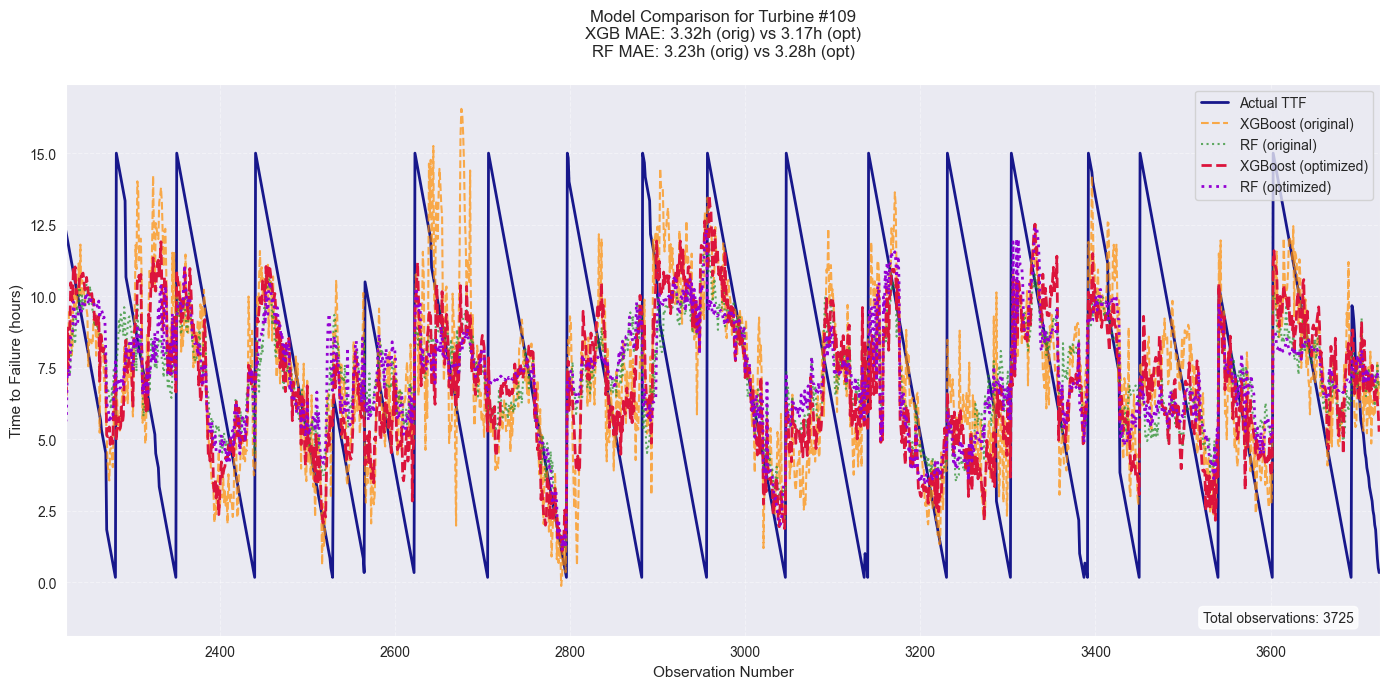

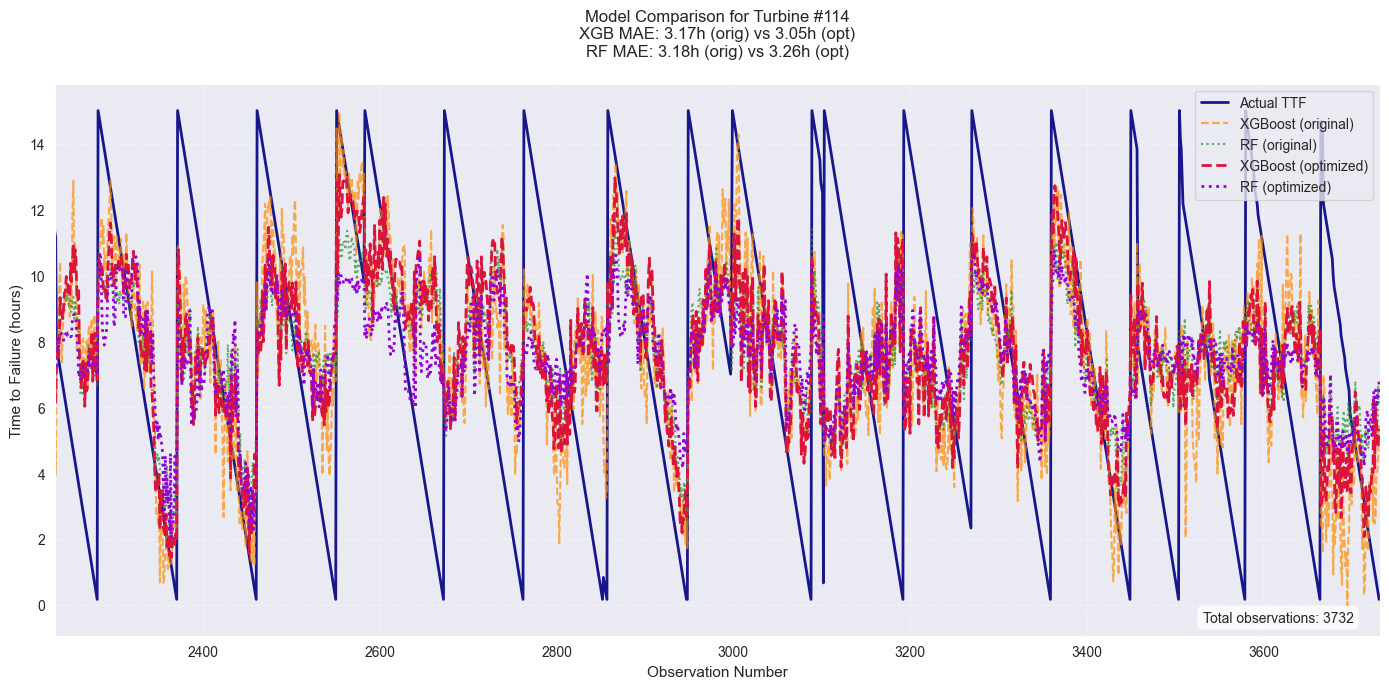

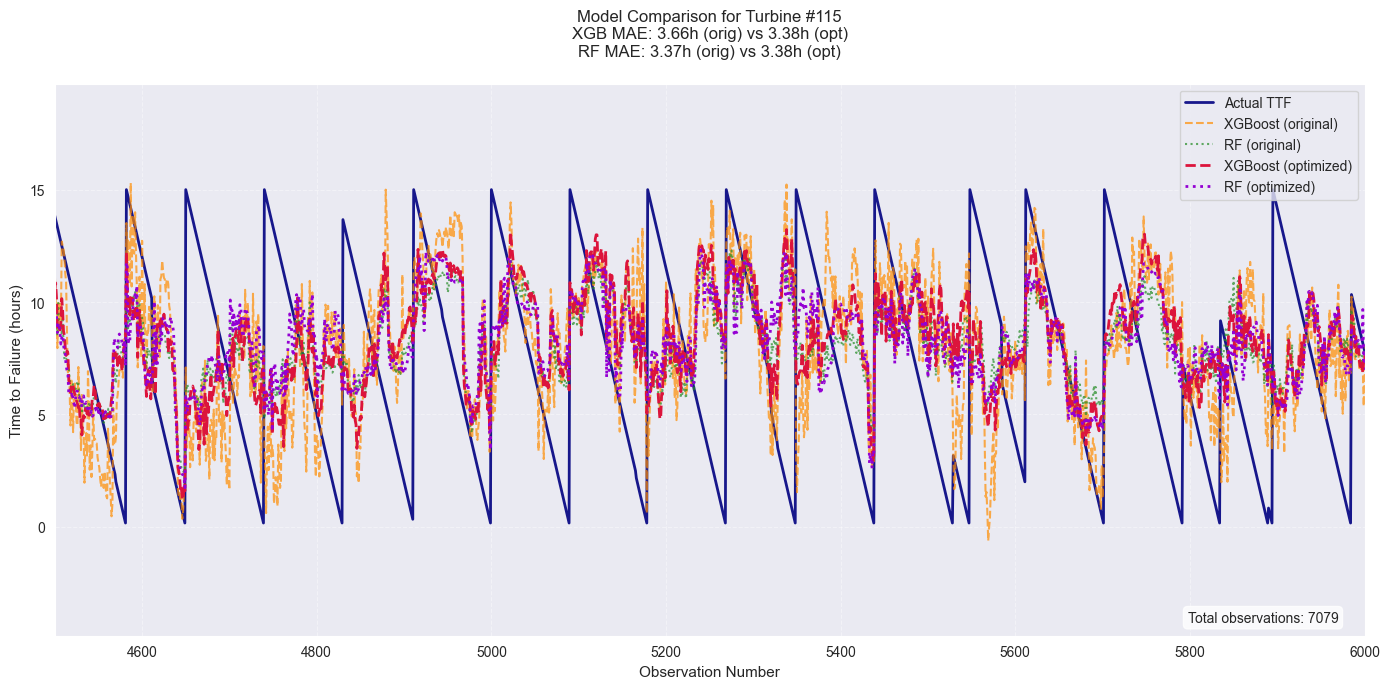

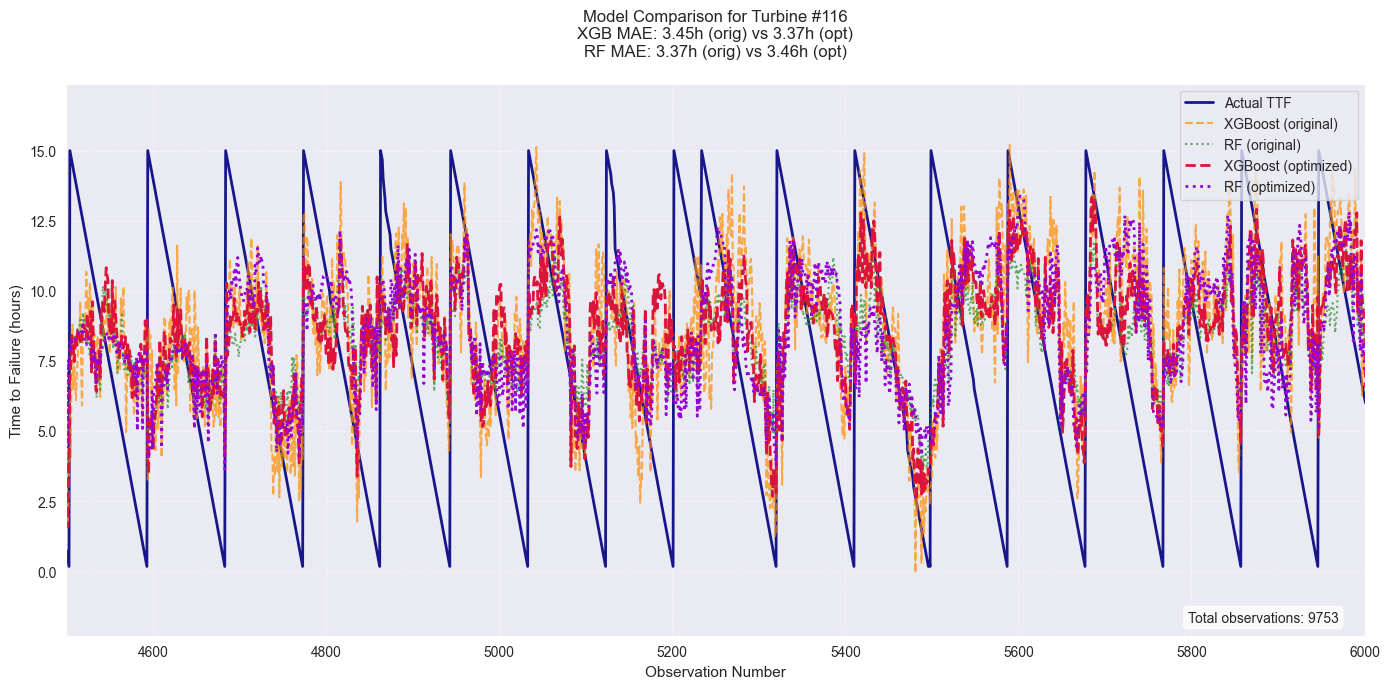

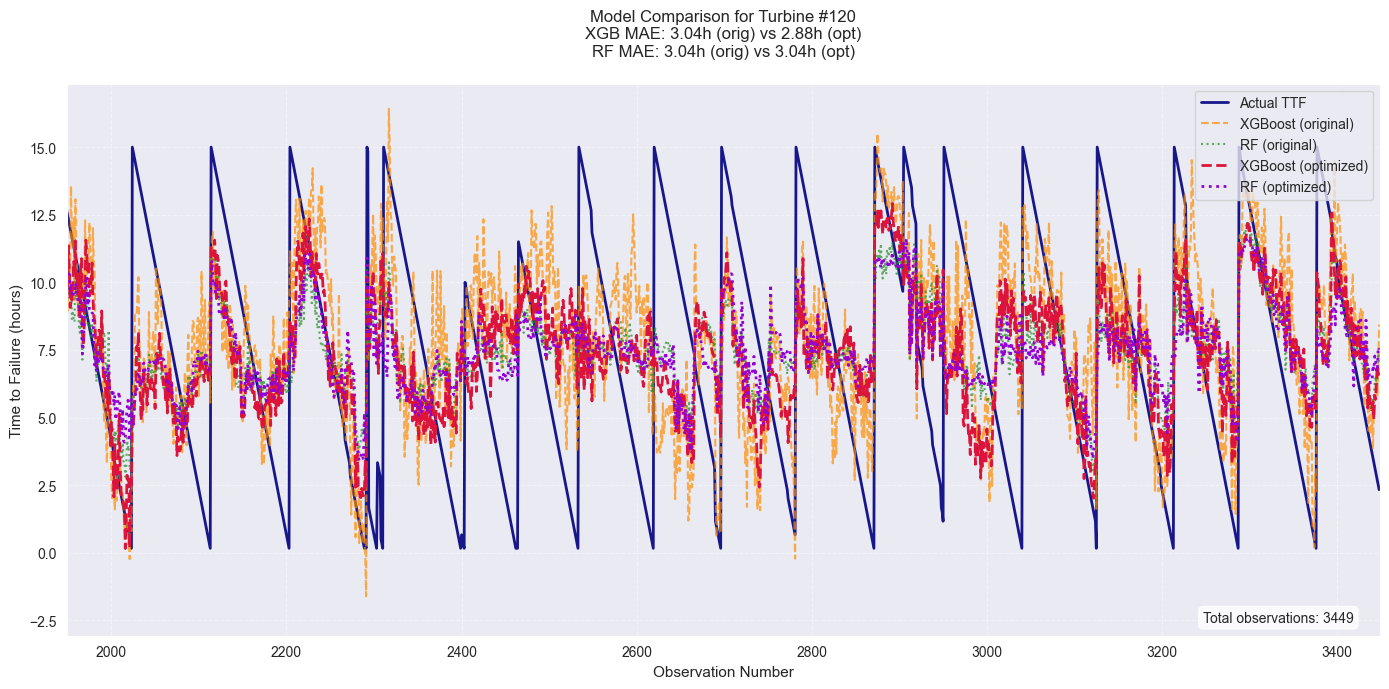

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ttf_comparison(turbine_id, predictions, xgb_mae_results, rf_mae_results, optimized_models=None):
    """
    Improved function to plot TTF predictions with better x-axis handling

    Parameters:
    - turbine_id: ID of the turbine to plot
    - predictions: Dictionary containing prediction data
    - xgb_mae_results: Dictionary of XGBoost MAE results
    - rf_mae_results: Dictionary of Random Forest MAE results
    - optimized_models: Dictionary containing optimized model results (optional)
    """

    if turbine_id not in predictions:
        print(f"No data for turbine {turbine_id}")
        return

    data = predictions[turbine_id]
    obs_numbers = np.arange(len(data['timestamps']))
    obs_count = len(obs_numbers)

    plt.figure(figsize=(14, 7))

    # Plot actual values
    plt.plot(obs_numbers, data['actual'],
             label='Actual TTF',
             color='navy',
             linewidth=2,
             alpha=0.9)

    # Plot original predictions
    plt.plot(obs_numbers, data['xgb_predicted'],
             label='XGBoost (original)',
             color='darkorange',
             linestyle='--',
             linewidth=1.5,
             alpha=0.7)

    plt.plot(obs_numbers, data['rf_predicted'],
             label='RF (original)',
             color='forestgreen',
             linestyle=':',
             linewidth=1.5,
             alpha=0.7)

    # Plot optimized predictions if available
    if optimized_models and 'xgb_optimized_predicted' in data:
        plt.plot(obs_numbers, data['xgb_optimized_predicted'],
                 label='XGBoost (optimized)',
                 color='crimson',
                 linestyle='--',
                 linewidth=2)

        plt.plot(obs_numbers, data['rf_optimized_predicted'],
                 label='RF (optimized)',
                 color='darkviolet',
                 linestyle=':',
                 linewidth=2)

        title = (f"Model Comparison for Turbine #{turbine_id}\n"
                f"XGB MAE: {xgb_mae_results[turbine_id]:.2f}h (orig) vs {optimized_models['xgb'][turbine_id]['mae']:.2f}h (opt)\n"
                f"RF MAE: {rf_mae_results[turbine_id]:.2f}h (orig) vs {optimized_models['rf'][turbine_id]['mae']:.2f}h (opt)")
    else:
        title = (f"Model Comparison for Turbine #{turbine_id}\n"
                f"XGB MAE: {xgb_mae_results[turbine_id]:.2f}h | RF MAE: {rf_mae_results[turbine_id]:.2f}h")

    # Set dynamic x-axis limits
    if obs_count > 5700:
        plt.xlim(4500, 6000)  # Focus on this range for large datasets
    elif obs_count > 1000:
        # For medium datasets, show last 1500 points
        plt.xlim(max(0, obs_count-1500), obs_count)
    # For small datasets, auto-scale

    # Formatting
    plt.title(title, pad=20, fontsize=12)
    plt.xlabel("Observation Number", fontsize=11)
    plt.ylabel("Time to Failure (hours)", fontsize=11)

    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.4)

    # Add annotation with observation count
    plt.annotate(f"Total observations: {obs_count}",
                xy=(0.98, 0.02),
                xycoords='axes fraction',
                ha='right',
                va='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# Example usage:
# First print observation counts for all turbines
print("\nObservation counts per turbine:")
for turbine_id in sorted(predictions.keys()):
    obs_count = len(predictions[turbine_id]['actual'])
    print(f"Turbine {turbine_id}: {obs_count} observations")

# Then plot each turbine with the improved function
for turbine_id in predictions.keys():
    plot_ttf_comparison(turbine_id, predictions, xgb_mae_results, rf_mae_results, optimized_models)